In [1]:
# Preparation step
import lseg.data as ld
from datetime import date, timedelta
import pandas as pd

import plotly.graph_objects as go

ld.open_session()

start = (date.today() - timedelta(days=730)).strftime('%Y-%m-%d')
end = date.today().strftime('%Y-%m-%d')

print(f'Start date: {start}, End date: {end}')

Start date: 2024-03-26, End date: 2026-03-26


In [2]:
# Step 1) Retrieve Gold Fixing Prices (XAUFIX=)
gold = ld.get_data(
    universe=['XAUFIX='],
    fields=['TR.ClosePrice'], # Closing price
    parameters={'SDate': start, 
                'EDate': end, 
                'Frq': 'D'}
)

display(gold.tail())

,Instrument,Close Price
518,XAUFIX=,4562.55
519,XAUFIX=,4466.25
520,XAUFIX=,4413.55
521,XAUFIX=,4564.55
522,XAUFIX=,4564.55


In [3]:
# Step 2) Calculate Historical Volatility

# Extract price series
price = gold['Close Price'].astype(float)

# Daily percentage returns
returns = price.pct_change()

# 30‑day rolling historical volatility (annualized)
hist_vol_30d = returns.rolling(30).std() * (252 ** 0.5)

# Combine for inspection
vol_df = pd.concat([
    price.rename('GoldPrice'),
    hist_vol_30d.rename('HV_30D')
], axis=1)

display(vol_df.tail())

,GoldPrice,HV_30D
518,4562.55,0.322625
519,4466.25,0.320639
520,4413.55,0.321389
521,4564.55,0.338150
522,4564.55,0.338114


In [4]:
# Step 3) Snapshot Implied Volatility (Using HST_CLOSE)
vol_rics = [
    'XAU10P3M=R','XAU15P3M=R','XAU20P3M=R','XAU25P3M=R',
    'XAU30P3M=R','XAU35P3M=R','XAU40P3M=R','XAU45P3M=R',
    'XAU3MO=R',
    'XAU45C3M=R','XAU40C3M=R','XAU35C3M=R','XAU30C3M=R',
    'XAU25C3M=R','XAU20C3M=R','XAU15C3M=R','XAU10C3M=R'
]

iv_data = {}

iv = ld.get_data(
    universe=vol_rics,
    fields=['HST_CLOSE']
)
display(iv.tail())

,Instrument,HST_CLOSE
12,XAU30C3M=R,29.783
13,XAU25C3M=R,30.292
14,XAU20C3M=R,30.999
15,XAU15C3M=R,31.82
16,XAU10C3M=R,32.673


In [6]:
# Step 4) Historical Implied Volatility (IV) Using MID_PRICE
iv_all = ld.get_history(
    universe=vol_rics,
    fields=['MID_PRICE'], # use MID_PRICE for IV history
    interval='1D',
    start=start,
    end=end
)
display(iv_all.tail())

MID_PRICE,XAU10P3M=R,XAU15P3M=R,XAU20P3M=R,XAU25P3M=R,XAU30P3M=R,XAU35P3M=R,XAU40P3M=R,XAU45P3M=R,XAU3MO=R,XAU45C3M=R,XAU40C3M=R,XAU35C3M=R,XAU30C3M=R,XAU25C3M=R,XAU20C3M=R,XAU15C3M=R,XAU10C3M=R
Date,,,,,,,,,,,,,,,,,
2026-03-19,27.562,26.82,26.192,25.744,25.494,25.39,25.381,25.418,25.456,25.501,25.609,25.836,26.235,26.854,27.68,28.626,29.607
2026-03-20,26.731,25.989,25.358,24.907,24.652,24.544,24.532,24.565,24.599,24.64,24.746,24.971,25.372,25.999,26.836,27.798,28.796
2026-03-23,34.072,33.239,32.532,32.02,31.706,31.533,31.446,31.391,31.323,31.262,31.271,31.412,31.741,32.31,33.094,33.999,34.937
2026-03-24,33.411,32.496,31.715,31.14,30.777,30.568,30.456,30.387,30.313,30.247,30.244,30.356,30.635,31.126,31.808,32.599,33.421
2026-03-25,32.308,31.406,30.64,30.082,29.743,29.56,29.476,29.433,29.38,29.33,29.339,29.463,29.755,30.262,30.966,31.784,32.633


In [7]:
# Step 5) Plot the Volatility Smile (Snapshot)
latest = iv_all.dropna().iloc[-1]

deltas = [10,15,20,25,30,35,40,45]

put_vols  = [latest[f"XAU{d}P3M=R"] for d in deltas]
call_vols = [latest[f"XAU{d}C3M=R"] for d in deltas[::-1]]
atm_vol   = latest["XAU3MO=R"]

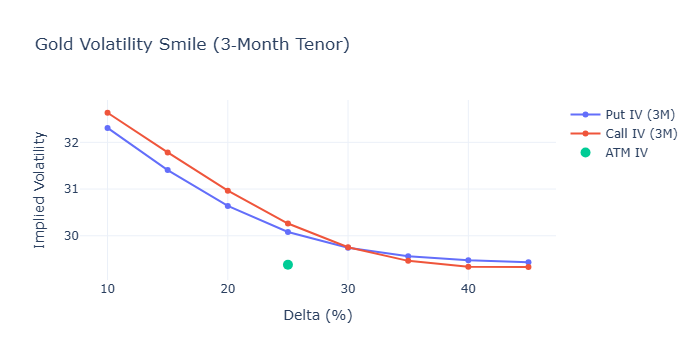

In [8]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=deltas, y=put_vols,
    mode="lines+markers",
    name="Put IV (3M)"
))

fig.add_trace(go.Scatter(
    x=deltas, y=call_vols[::-1],
    mode="lines+markers",
    name="Call IV (3M)"
))

fig.add_trace(go.Scatter(
    x=[25], y=[atm_vol],
    mode="markers",
    marker=dict(size=10),
    name="ATM IV"
))

fig.update_layout(
    title="Gold Volatility Smile (3‑Month Tenor)",
    xaxis_title="Delta (%)",
    yaxis_title="Implied Volatility",
    template="plotly_white"
)

fig.show()

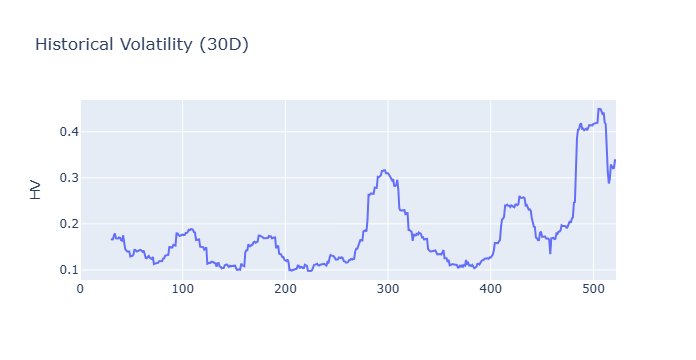

In [9]:
# Step 6) Plot Historical Volatility (HV Only)
fig = go.Figure()
fig.add_trace(go.Scatter(x=hist_vol_30d.index, y=hist_vol_30d))
fig.update_layout(title="Historical Volatility (30D)", yaxis_title="HV")
fig.show()

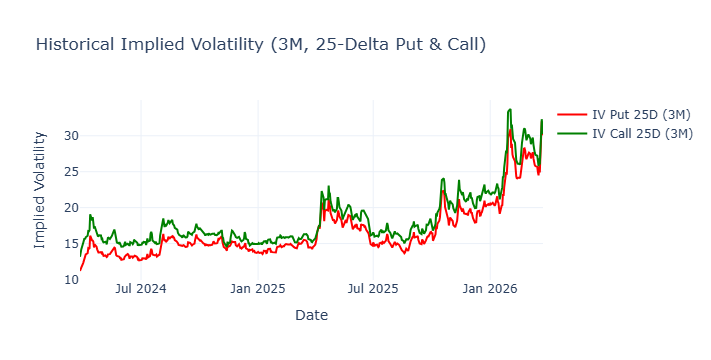

In [10]:
# Step 7) Plot Historical Implied Vol (IV Only)
iv_put_25d  = iv_all["XAU25P3M=R"].dropna()
iv_call_25d = iv_all["XAU25C3M=R"].dropna()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=iv_put_25d.index,
    y=iv_put_25d,
    mode="lines",
    name="IV Put 25D (3M)",
    line=dict(color="red", width=2)
))

fig.add_trace(go.Scatter(
    x=iv_call_25d.index,
    y=iv_call_25d,
    mode="lines",
    name="IV Call 25D (3M)",
    line=dict(color="green", width=2)
))

fig.update_layout(
    title="Historical Implied Volatility (3M, 25-Delta Put & Call)",
    xaxis_title="Date",
    yaxis_title="Implied Volatility",
    template="plotly_white"
)

fig.show()

In [11]:
ld.close_session()